In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler

Explained Variance per PC:
  PC1: 72.96%   cumulative: 72.96%
  PC2: 22.85%   cumulative: 95.81%
  PC3: 3.67%   cumulative: 99.48%
  PC4: 0.52%   cumulative: 100.00%


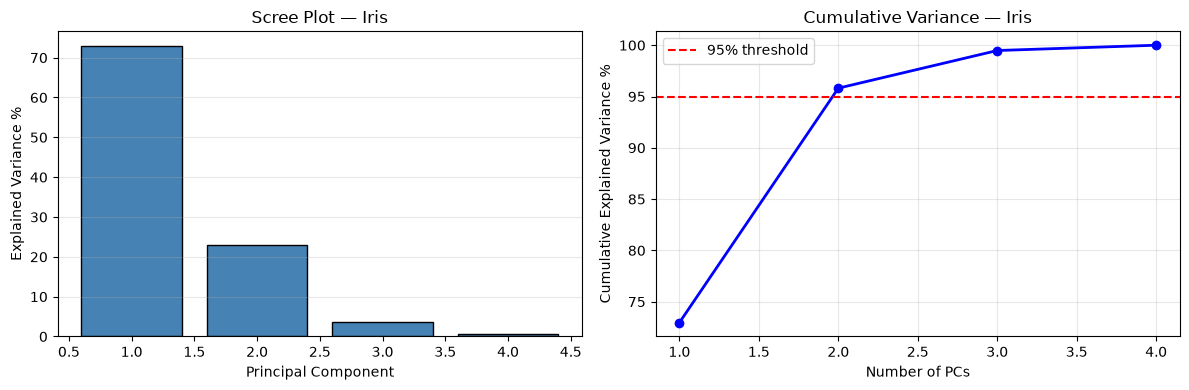

In [2]:
# Cell 2 — Version 1: explained variance on Iris
iris = load_iris()
X    = StandardScaler().fit_transform(iris.data)

pca  = PCA()
pca.fit(X)

ev_ratio  = pca.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)

print("Explained Variance per PC:")
for i, (ev, cum) in enumerate(zip(ev_ratio, ev_cumsum)):
    print(f"  PC{i+1}: {ev*100:.2f}%   cumulative: {cum*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(ev_ratio)+1), ev_ratio*100,
            color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance %')
axes[0].set_title('Scree Plot — Iris')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(range(1, len(ev_cumsum)+1), ev_cumsum*100, 'b-o', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Explained Variance %')
axes[1].set_title('Cumulative Variance — Iris')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Total features:          64
PCs for 95% variance:    40
PCs for 99% variance:    54
Compression ratio (95%): 1.6x


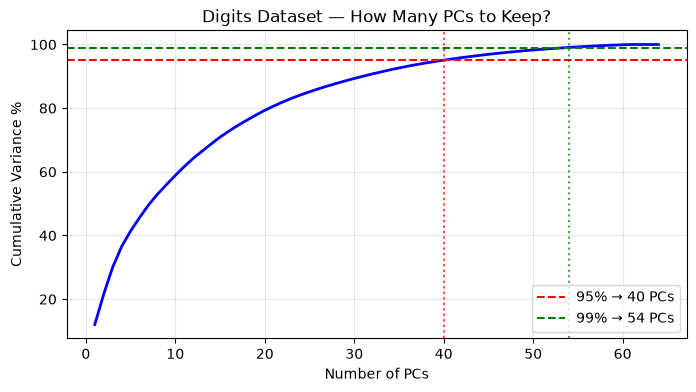

In [3]:
# Cell 3 — Version 2: digits dataset (64 features → find optimal PCs)
digits = load_digits()
X      = StandardScaler().fit_transform(digits.data)

pca    = PCA()
pca.fit(X)

ev_cumsum = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(ev_cumsum >= 0.95) + 1
n_99 = np.argmax(ev_cumsum >= 0.99) + 1

print(f"Total features:          {X.shape[1]}")
print(f"PCs for 95% variance:    {n_95}")
print(f"PCs for 99% variance:    {n_99}")
print(f"Compression ratio (95%): {X.shape[1]/n_95:.1f}x")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(ev_cumsum)+1), ev_cumsum*100, 'b-', linewidth=2)
plt.axhline(95, color='red',   linestyle='--', label=f'95% → {n_95} PCs')
plt.axhline(99, color='green', linestyle='--', label=f'99% → {n_99} PCs')
plt.axvline(n_95, color='red',   linestyle=':', alpha=0.7)
plt.axvline(n_99, color='green', linestyle=':', alpha=0.7)
plt.xlabel('Number of PCs'); plt.ylabel('Cumulative Variance %')
plt.title('Digits Dataset — How Many PCs to Keep?')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

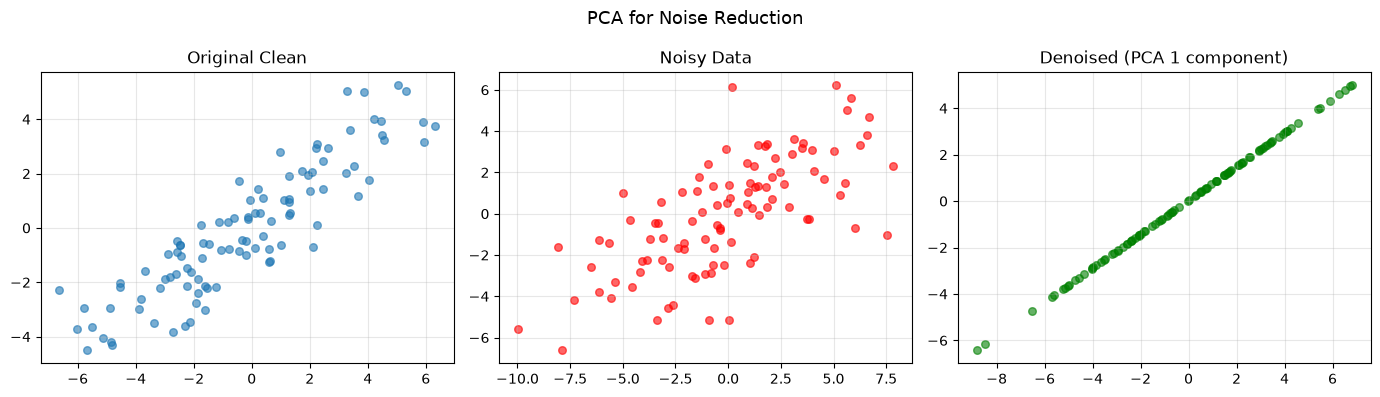

In [4]:
# Cell 4 — Version 3: PCA for noise reduction
np.random.seed(42)
X_clean = np.dot(np.random.randn(100, 2), [[3, 1.5],[1.5, 2]])
X_noisy = X_clean + np.random.randn(100, 2) * 1.5

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_noisy)

pca      = PCA(n_components=1)
X_reduced    = pca.fit_transform(X_scaled)
X_denoised   = pca.inverse_transform(X_reduced)
X_denoised   = scaler.inverse_transform(X_denoised)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(X_clean[:,0],   X_clean[:,1],   alpha=0.6, s=30)
axes[0].set_title('Original Clean'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_noisy[:,0],   X_noisy[:,1],   alpha=0.6, s=30, color='red')
axes[1].set_title('Noisy Data'); axes[1].grid(True, alpha=0.3)

axes[2].scatter(X_denoised[:,0], X_denoised[:,1], alpha=0.6, s=30, color='green')
axes[2].set_title('Denoised (PCA 1 component)'); axes[2].grid(True, alpha=0.3)

plt.suptitle('PCA for Noise Reduction', fontsize=13)
plt.tight_layout(); plt.show()

In [5]:
# Cell 5 — Version 4: PCA before classification — speed vs accuracy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}
for n_comp in [5, 10, 20, 30, 64]:
    if n_comp < 64:
        pca    = PCA(n_components=n_comp)
        Xtr    = pca.fit_transform(X_train)
        Xte    = pca.transform(X_test)
    else:
        Xtr, Xte = X_train, X_test

    t0  = time.time()
    rf  = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(Xtr, y_train)
    acc = accuracy_score(y_test, rf.predict(Xte))
    t1  = time.time()
    results[n_comp] = (acc, t1-t0)
    print(f"n_components={n_comp:3d} | acc={acc*100:.1f}% | time={t1-t0:.2f}s")

print("\nPCA reduces features with minimal accuracy loss ✅")

n_components=  5 | acc=86.7% | time=0.21s
n_components= 10 | acc=93.6% | time=0.26s
n_components= 20 | acc=96.4% | time=0.25s
n_components= 30 | acc=96.1% | time=0.37s
n_components= 64 | acc=96.9% | time=0.30s

PCA reduces features with minimal accuracy loss ✅
